<a href="https://colab.research.google.com/github/codedbyekta/AI-Model-Lab/blob/main/Sentiment_and_Emotion_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import re
import nltk

from nltk.corpus import stopwords
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [2]:
train_df = pd.read_csv("/content/training.csv.xls")
val_df   = pd.read_csv("/content/validation.csv.xls")
test_df  = pd.read_csv("/content/test.csv.xls")

print(train_df.head())

                                                text  label
0                            i didnt feel humiliated      0
1  i can go from feeling so hopeless to so damned...      0
2   im grabbing a minute to post i feel greedy wrong      3
3  i am ever feeling nostalgic about the fireplac...      2
4                               i am feeling grouchy      3


In [3]:
mapping = {
    0: "sadness",
    1: "joy",
    2: "love",
    3: "anger",
    4: "fear",
    5: "surprise"
}

train_df["emotion_name"] = train_df["label"].map(mapping)
val_df["emotion_name"]   = val_df["label"].map(mapping)
test_df["emotion_name"]  = test_df["label"].map(mapping)

In [4]:
def emotion_to_sentiment(emotion):
    if emotion in ["joy", "love"]:
        return "positive"
    elif emotion in ["sadness", "anger", "fear"]:
        return "negative"
    else:
        return "neutral"

train_df["sentiment"] = train_df["emotion_name"].apply(emotion_to_sentiment)
val_df["sentiment"]   = val_df["emotion_name"].apply(emotion_to_sentiment)
test_df["sentiment"]  = test_df["emotion_name"].apply(emotion_to_sentiment)

In [5]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^\w\s!?]', '', text)

    words = text.split()
    words = [word for word in words if word not in stop_words]

    return " ".join(words)

In [6]:
train_df["clean_text"] = train_df["text"].apply(clean_text)
val_df["clean_text"]   = val_df["text"].apply(clean_text)
test_df["clean_text"]  = test_df["text"].apply(clean_text)

In [7]:
train_df.to_csv("train_cleaned.csv", index=False)
val_df.to_csv("val_cleaned.csv", index=False)
test_df.to_csv("test_cleaned.csv", index=False)

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))

X_train = tfidf.fit_transform(train_df["clean_text"])
X_val   = tfidf.transform(val_df["clean_text"])

In [9]:
from sklearn.linear_model import LogisticRegression

emotion_model = LogisticRegression(max_iter=1000, class_weight='balanced')
emotion_model.fit(X_train, train_df["label"])

LogisticRegression(class_weight='balanced', max_iter=1000)

In [10]:
sentiment_model = LogisticRegression(max_iter=1000)
sentiment_model.fit(X_train, train_df["sentiment"])

LogisticRegression(max_iter=1000)

In [11]:
from sklearn.metrics import accuracy_score, classification_report

In [12]:
# Transform validation text
X_val_tfidf = tfidf.transform(val_df["clean_text"])

# Predictions
y_pred_emo = emotion_model.predict(X_val_tfidf)
y_pred_sent = sentiment_model.predict(X_val_tfidf)

In [13]:
print("Emotion Accuracy:", accuracy_score(val_df["label"], y_pred_emo))
print("Sentiment Accuracy:", accuracy_score(val_df["sentiment"], y_pred_sent))

Emotion Accuracy: 0.9035
Sentiment Accuracy: 0.953


In [14]:
print("\nEmotion Report:\n")
print(classification_report(val_df["label"], y_pred_emo))

print("\nSentiment Report:\n")
print(classification_report(val_df["sentiment"], y_pred_sent))


Emotion Report:

              precision    recall  f1-score   support

           0       0.94      0.92      0.93       550
           1       0.95      0.89      0.92       704
           2       0.78      0.95      0.86       178
           3       0.91      0.93      0.92       275
           4       0.86      0.83      0.85       212
           5       0.72      0.90      0.80        81

    accuracy                           0.90      2000
   macro avg       0.86      0.90      0.88      2000
weighted avg       0.91      0.90      0.90      2000


Sentiment Report:

              precision    recall  f1-score   support

    negative       0.94      0.98      0.96      1037
     neutral       0.91      0.59      0.72        81
    positive       0.97      0.96      0.96       882

    accuracy                           0.95      2000
   macro avg       0.94      0.84      0.88      2000
weighted avg       0.95      0.95      0.95      2000



In [15]:
# ===== MANUAL TESTING =====

# emotion mapping (for readable output)
emotion_map = {
    0: "sadness",
    1: "joy",
    2: "love",
    3: "anger",
    4: "fear",
    5: "surprise"
}

# take input
text = input("Enter a sentence: ")

# clean
clean = clean_text(text)

# vectorize
vec = tfidf.transform([clean])

# predict
emotion_pred = emotion_model.predict(vec)[0]
sentiment_pred = sentiment_model.predict(vec)[0]

# convert emotion number -> name
emotion_name = emotion_map[emotion_pred]

# output
print("\n🔍 Result:")
print("Text:", text)
print("Emotion:", emotion_name)
print("Sentiment:", sentiment_pred)

Enter a sentence: i love me.

🔍 Result:
Text: i love me.
Emotion: love
Sentiment: positive


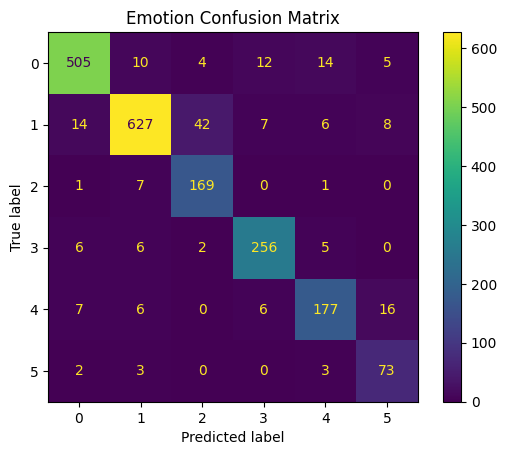

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(val_df["label"], y_pred_emo)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Emotion Confusion Matrix")
plt.show()

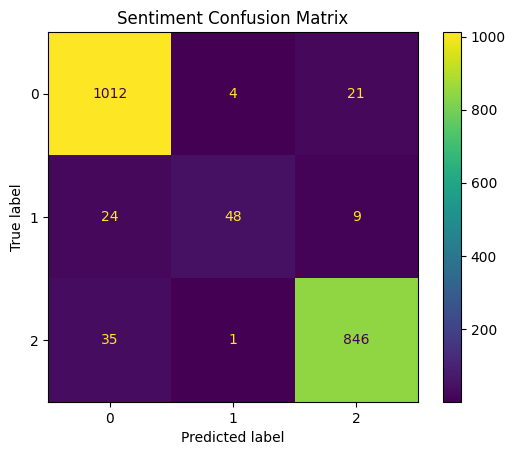

In [17]:
cm_sent = confusion_matrix(val_df["sentiment"], y_pred_sent)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_sent)
disp.plot()
plt.title("Sentiment Confusion Matrix")
plt.show()

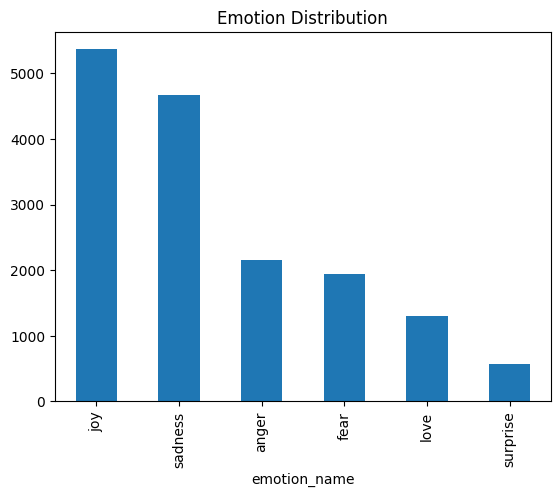

In [18]:
# a lil EDA 👀
train_df["emotion_name"].value_counts().plot(kind='bar')
plt.title("Emotion Distribution")
plt.show()

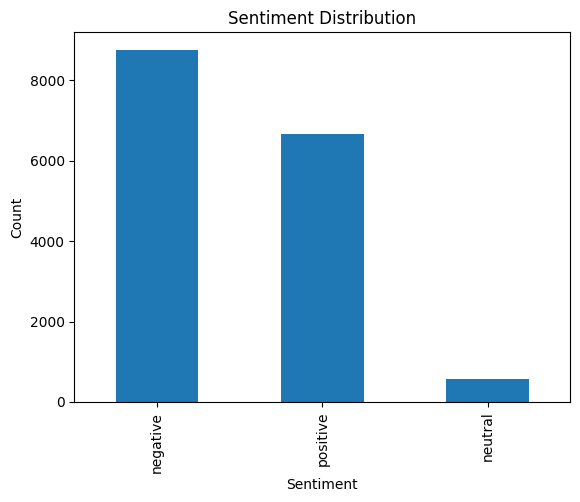

In [19]:
train_df["sentiment"].value_counts().plot(kind='bar')
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

In [20]:
import joblib

joblib.dump(tfidf, "tfidf_vectorizer.pkl")
joblib.dump(emotion_model, "emotion_model.pkl")
joblib.dump(sentiment_model, "sentiment_model.pkl")

print("Models saved!")

Models saved!
